# Sentiment-Analyse der Zeitungsartikel (NRC Emotion Lexicon)

Dieses Notebook baut auf der Artikel-Extraktion auf (`articles_extracted.csv`
bzw. deine Excel-Datei im gleichen Format: Spalten `pdf_page`, `year`,
`month`, `word_count`, `text`, optional `source_file`/`lang`/
`has_agency_marker`) und führt darauf eine **Dokument-Level Sentiment-
Analyse mit dem NRC Emotion Lexicon** durch.

**Ablauf:**

1. Artikel laden (Excel oder CSV)
2. Sprache pro Artikel sicherstellen (Deutsch/Englisch — falls die Spalte
   `lang` fehlt, wird sie hier nachträglich bestimmt)
3. NRC-Lexikon laden — **Deutsch und Englisch**, aus der offiziellen
   mehrsprachigen NRC-Datei (Google-Translate-Übersetzungen der
   englischen Originalwörter)
4. Umlaut-Transliteration des deutschen Lexikons (`für` → `fuer` usw.,
   wie im historischen Zeitungssatz üblich)
5. Tokenisierung/Lemmatisierung pro Artikel (spaCy, sprachabhängig)
6. Dokument-Level Scoring: relative Häufigkeit pro Emotion, normalisiert
   auf Textlänge
7. Aggregation nach Jahr + Visualisierung des Stimmungsverlaufs
8. Ranking der Artikel je Emotion/Jahr → Closer Reading
9. Coverage-Check (wie viel Prozent der Wörter matchen überhaupt im
   Lexikon?) — wichtig zur Einordnung der Ergebnisse


## 0. Setup

Benötigt: `pandas`, `openpyxl` (Excel), `spacy` mit den Modellen
`de_core_news_sm` und `en_core_web_sm`, `langdetect`, `matplotlib`,
`rapidfuzz` (Fuzzy-Matching, Abschnitt 5).

```bash
pip install pandas openpyxl spacy langdetect matplotlib rapidfuzz compound-split scipy statsmodels
python -m spacy download de_core_news_sm
python -m spacy download en_core_web_sm
```


In [141]:
#!pip install pandas openpyxl spacy langdetect matplotlib rapidfuzz compound-split scipy statsmodels
#!python -m spacy download de_core_news_sm
#!python -m spacy download en_core_web_sm

import re
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import spacy
import os
import glob
from rapidfuzz import process, fuzz
from compound_split import char_split
from scipy import stats
from statsmodels.stats.multitest import multipletests
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0
warnings.filterwarnings("ignore")

print("Lade spaCy-Modelle (Deutsch + Englisch) ...")
nlp_de = spacy.load("de_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")
print("Fertig.")


Lade spaCy-Modelle (Deutsch + Englisch) ...
Fertig.


## 1. Artikel laden

Passe `ARTICLES_PATH` auf deine Datei an. Funktioniert sowohl mit `.xlsx`
als auch `.csv` (wird automatisch anhand der Dateiendung erkannt).


In [114]:
ARTICLES_PATH = "articles_extracted.csv"  # <-- ggf. auf deine .xlsx anpassen

def load_articles(path):
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    return df

articles = load_articles(ARTICLES_PATH)
print(f"{len(articles)} Artikel geladen.")
print("Spalten:", list(articles.columns))
articles.head(3)


1046 Artikel geladen.
Spalten: ['source_file', 'pdf_page', 'year', 'month', 'lang', 'has_agency_marker', 'word_count', 'text']


,source_file,pdf_page,year,month,lang,has_agency_marker,word_count,text
0,shanghaijewishch00unse.pdf,1,NaN,NaN,en,False,117,Aa Bb Cc Dd Ee Ff Gg Hh li Jj Kk LI Mm Nn Oo P...
1,shanghaijewishch00unse.pdf,4,1939.0,6.0,de,False,580,problems. Ein Lichtstrahl in der Finsternis Wi...
2,shanghaijewishch00unse.pdf,4,1939.0,6.0,de,True,66,"ın Genua Koffer mit Lire 1,000,000 Inhalt gefu..."


## 1b. Datenbereinigung

Drei Dinge, die sich an einer echten, größeren Extraktion gezeigt haben
und die man vor der Sentiment-Analyse beheben sollte:

**a) Jahres-Plausibilitätsfilter + Auffüllen.** OCR verliest die Jahreszahl
im Masthead gelegentlich (z.B. „1194" oder „7941" statt „1941"). Unplausible
Werte (außerhalb des bekannten Erscheinungszeitraums) werden entfernt und
über benachbarte Seiten **derselben Datei** aufgefüllt (Ausgaben sind
mehrseitig zusammenhängend) — ändere `YEAR_MIN`/`YEAR_MAX`, falls dein
Korpus einen anderen Zeitraum abdeckt.

**b) OCR-Strichsalat rausfiltern.** Manche Blöcke aus sehr dicht gesetzten
Anzeigenseiten bestehen fast nur aus Strichen/Symbolen statt echtem Text
(z.B. `"— — — al — — na — ="`) und rutschen durch den Anzeigen-Filter
durch, weil sie technisch "lang genug" sind. Sie fallen u.a. dadurch auf,
dass `langdetect` sie fälschlich als exotische Sprache einordnet (Französisch,
Walisisch, ...) — das ist selbst ein Hinweis auf Datenmüll, aber
wir filtern direkt über den Anteil nicht-alphabetischer "Wörter".

**c) Führende Ziffern entfernen.** Vereinzelt hängt eine Anzeigen-
Referenznummer am Artikelanfang (z.B. `"52825 Aktionen gegen..."`) —
vermutlich aus einem Nachbarblock reingerutscht.


In [115]:
YEAR_MIN, YEAR_MAX = 1938, 1946  # bekannter Erscheinungszeitraum -- anpassen!
JUNK_RATIO_THRESHOLD = 0.3        # Anteil nicht-alphabetischer "Woerter"

def clean_leading_number(text):
    return re.sub(r"^\d+\s+", "", text)

def junk_ratio(text):
    tokens = text.split()
    if not tokens:
        return 1.0
    non_alpha = sum(1 for t in tokens if not re.search(r"[a-zA-Z\u00e4\u00f6\u00fc\u00c4\u00d6\u00dc\u00df]{2,}", t))
    return non_alpha / len(tokens)


n_before = len(articles)

# a) Jahres-Plausibilitaetsfilter + Auffuellen pro Quelldatei
if "year" in articles.columns:
    articles = articles.sort_values(
        [c for c in ["source_file", "pdf_page"] if c in articles.columns]
    ).reset_index(drop=True)
    valid_year = articles["year"].between(YEAR_MIN, YEAR_MAX)
    n_invalid = (~valid_year & articles["year"].notna()).sum()
    articles.loc[~valid_year, "year"] = None
    group_col = "source_file" if "source_file" in articles.columns else None
    if group_col:
        articles["year"] = articles.groupby(group_col)["year"].transform(lambda s: s.ffill().bfill())
    else:
        articles["year"] = articles["year"].ffill().bfill()
    print(f"Unplausible Jahre entfernt: {n_invalid}")
    print(f"Fehlende Jahre nach Auffuellen: {articles['year'].isna().sum()}")

# b) OCR-Strichsalat rausfiltern
articles["junk_ratio"] = articles["text"].apply(junk_ratio)
n_junk = (articles["junk_ratio"] > JUNK_RATIO_THRESHOLD).sum()
articles = articles[articles["junk_ratio"] <= JUNK_RATIO_THRESHOLD].drop(columns=["junk_ratio"]).reset_index(drop=True)
print(f"Als OCR-Muell entfernt: {n_junk}")

# c) Fuehrende Ziffern entfernen
articles["text"] = articles["text"].apply(clean_leading_number)

print(f"\n{n_before} -> {len(articles)} Artikel nach Bereinigung.")


Unplausible Jahre entfernt: 20
Fehlende Jahre nach Auffuellen: 0
Als OCR-Muell entfernt: 33

1046 -> 1013 Artikel nach Bereinigung.


## 2. Sprache pro Artikel sicherstellen

Falls die Spalte `lang` schon existiert (aus der Extraktions-Pipeline),
wird sie übernommen. Falls nicht, wird sie hier nachträglich bestimmt.
Das ist wichtig, weil die Zeitung als *"English and German Editions"*
erscheint — Deutsch und Englisch brauchen jeweils ihr eigenes NRC-Lexikon.


In [116]:
def detect_language(text):
    if not isinstance(text, str) or len(text.split()) < 5:
        return "unknown"
    try:
        return detect(text)
    except Exception:
        return "unknown"

if "lang" not in articles.columns:
    print("Keine 'lang'-Spalte gefunden -- bestimme Sprache pro Artikel ...")
    articles["lang"] = articles["text"].apply(detect_language)

print(articles["lang"].value_counts())


lang
de    965
en     48
Name: count, dtype: int64


## 3. NRC-Lexikon laden (Deutsch + Englisch)

Die offizielle NRC-Emotion-Lexicon-Website (saifmohammad.com) verlangt für
die mehrsprachige Version ein kurzes Lizenz-Formular (Forschungsnutzung).
Falls du die Datei `NRC-Emotion-Lexicon-v0.92-InManyLanguages-web.xlsx`
noch nicht hast: dort herunterladen (Lizenzbedingungen akzeptieren,
Forschungsnutzung ist der Standardfall) und in den Projektordner legen.

**Spaltenaufbau der Datei** (Stand dieser Version): Spalte 0 = englisches
Wort, Spalte 12 = deutsche Übersetzung, Spalten 41–50 = die zehn
NRC-Kategorien (Positive, Negative, Anger, Anticipation, Disgust, Fear,
Joy, Sadness, Surprise, Trust) als 0/1-Flags. Der Code unten sucht die
Spalten über ihre **Namen** statt über feste Indizes — robuster, falls
sich die Spaltenreihenfolge in deiner Version leicht unterscheidet.


In [117]:
NRC_PATH = "NRC-Emotion-Lexicon-v0.92-InManyLanguages-web.xlsx"

EMOTIONS = ["Positive", "Negative", "Anger", "Anticipation", "Disgust",
            "Fear", "Joy", "Sadness", "Surprise", "Trust"]


def load_nrc_lexicon(path, emotions=EMOTIONS):
    """Laedt die mehrsprachige NRC-Datei und baut zwei Lexika:
    Englisch (Wort -> Set von Emotionen) und Deutsch (uebersetztes
    Wort -> Set von Emotionen)."""
    df = pd.read_excel(path)

    # Spalten ueber Namen finden statt feste Indizes -- robuster gegenueber
    # leicht abweichenden Dateiversionen.
    en_col = "English Word"
    de_col = [c for c in df.columns if c.startswith("German")][0]
    emotion_cols = {e: e for e in emotions if e in df.columns}
    missing = set(emotions) - set(emotion_cols)
    if missing:
        raise ValueError(f"Emotion-Spalten nicht gefunden: {missing}. "
                          f"Verfuegbare Spalten: {list(df.columns)}")

    lex_en, lex_de = {}, {}
    for _, row in df.iterrows():
        active_emotions = {e for e in emotions if row.get(e) == 1}
        if not active_emotions:
            continue  # Wort ohne jede Emotionszuordnung ueberspringen

        en_word = str(row[en_col]).strip().lower()
        if en_word and en_word != "nan":
            lex_en.setdefault(en_word, set()).update(active_emotions)

        de_word = row[de_col]
        if isinstance(de_word, str) and de_word.strip():
            de_word = de_word.strip().lower()
            lex_de.setdefault(de_word, set()).update(active_emotions)

    return lex_en, lex_de


lex_en, lex_de = load_nrc_lexicon(NRC_PATH)
print(f"Englisches Lexikon: {len(lex_en)} Woerter")
print(f"Deutsches Lexikon (vor Transliteration): {len(lex_de)} Woerter")


Englisches Lexikon: 6468 Woerter
Deutsches Lexikon (vor Transliteration): 4597 Woerter


## 4. Umlaut-Transliteration des deutschen Lexikons

Der historische Zeitungssatz verwendet durchgängig `ae/oe/ue/ss` statt
`ä/ö/ü/ß` (kein Umlaut im damaligen Bleisatz-/Telegrafie-Zeichensatz
verfügbar) — kein OCR-Fehler, sondern so wurde tatsächlich gedruckt. Wir
erweitern das Lexikon um transliterierte Zusatzeinträge (`für` → auch
`fuer`), damit beide Schreibweisen matchen.


In [118]:
_UMLAUT_MAP = str.maketrans({"ä": "ae", "ö": "oe", "ü": "ue"})


def delatinize(word):
    word = word.replace("ß", "ss")
    return word.translate(_UMLAUT_MAP)


def delatinize_lexicon(word2emotions):
    extended = dict(word2emotions)
    for word, emotions in word2emotions.items():
        alt = delatinize(word)
        if alt != word:
            extended[alt] = extended.get(alt, set()) | emotions
    return extended


lex_de = delatinize_lexicon(lex_de)
print(f"Deutsches Lexikon (nach Transliteration): {len(lex_de)} Woerter")

# Kurzer Test:
print("'fuer' im Lexikon:", "fuer" in lex_de, "->", lex_de.get("fuer"))


Deutsches Lexikon (nach Transliteration): 5463 Woerter
'fuer' im Lexikon: False -> None


## 5. Tokenisierung/Lemmatisierung

Pro Artikel: Text lemmatisieren (sprachabhängiges spaCy-Modell). **Wichtiger
Fix:** spaCys deutsches Modell großschreibt Nomen-Lemmata auch bei klein
geschriebener Eingabe (`polizei` → `Polizei`), unser Lexikon ist aber
durchgängig klein geschrieben — ohne `.lower()` auf das Lemma verliert man
dadurch unnötig Coverage.

**Zusätzlich: POS-Filter.** Über `is_stop` hinaus schließen wir gezielt
Wortarten aus, die im NRC-Lexikon ohnehin nie etwas beitragen (Pronomen,
Artikel, Hilfsverben, Zahlen, Konjunktionen — spaCys Stoppwortliste fängt
nicht alle davon ab). Das bringt zwar nur ein bis zwei Prozentpunkte, ist
aber komplett risikofrei (entfernt nur Wörter, die sowieso nie matchen
würden) und schrumpft den Nenner der Coverage-Berechnung sauber.

**Zusätzlich: sprachübergreifende Stopwortliste — aber mit Sicherheitsnetz.**
Die Zeitung ist zweisprachig, und manche extrahierten "Artikel" enthalten
tatsächlich gemischtsprachigen Text (z.B. wenn zwei benachbarte Leserbriefe
— einer deutsch, einer englisch — bei der Extraktion zu einem Block
zusammengefasst wurden). Das jeweils verwendete Sprachmodell kennt die
Stopwörter der JEWEILS ANDEREN Sprache nicht (`the` bleibt für das
deutsche Modell ein normales Wort, `der` für das englische) — dadurch
rutschen fremdsprachige Funktionswörter ungefiltert durch.

**Wichtig — eine simple Vereinigung beider Stopwortlisten wäre hier ein
Fehler:** Manche deutschen Stopwörter sind zufällig auch echte, stark
emotionsgeladene ENGLISCHE Wörter — allen voran `war` (Krieg!) und `die`
(sterben!), außerdem `gut` (engl. "Bauch/Mumm"), `wart`/`wen`
(medizinische Fachbegriffe). Eine blinde Kombi-Liste würde `war`/`die` aus
JEDEM englischen Artikel rausfiltern — bei einer Zeitung aus der
Kriegszeit ein spürbarer Informationsverlust, kein Randfall. Deshalb
filtern wir ein fremdsprachiges Stopwort nur dann, wenn es NICHT zufällig
im Emotionslexikon der jeweiligen Artikelsprache steht:


In [119]:
from spacy.lang.de.stop_words import STOP_WORDS as DE_STOP_WORDS
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP_WORDS

CONTENT_POS = {"NOUN", "PROPN", "VERB", "ADJ", "ADV"}

def lemmatize(text, lang):
    nlp = nlp_de if lang == "de" else nlp_en
    primary_lexicon = lex_de if lang == "de" else lex_en
    cross_lang_stop = EN_STOP_WORDS if lang == "de" else DE_STOP_WORDS  # JEWEILS ANDERE Sprache

    doc = nlp(str(text).lower())
    result = []
    for tok in doc:
        if not tok.is_alpha or tok.is_stop or tok.pos_ not in CONTENT_POS:
            continue
        lemma = tok.lemma_.lower()
        # Fremdsprachiges Stopwort NUR rausfiltern, wenn es nicht zufaellig
        # ein echtes Emotionswort der eigentlichen Artikelsprache ist
        # (z.B. "war"/"die" sind deutsche Stopwoerter, aber im Englischen
        # stark emotionsgeladene Woerter -- die sollen bleiben).
        if lemma in cross_lang_stop and lemma not in primary_lexicon:
            continue
        result.append((lemma, tok.pos_))
    return result


articles["_lang_used"] = articles["lang"].where(articles["lang"].isin(["de", "en"]), "de")

print("Lemmatisiere Artikel (kann je nach Anzahl ein paar Minuten dauern) ...")
articles["_lemmas_pos"] = [
    lemmatize(text, lang) for text, lang in zip(articles["text"], articles["_lang_used"])
]
print("Fertig.")


Lemmatisiere Artikel (kann je nach Anzahl ein paar Minuten dauern) ...
Fertig.


**Falls dir die gemischtsprachigen Artikel selbst wichtig sind** (nicht nur
die Stopwörter in den Themenlisten, sondern eine korrekte Emotions-
Zuordnung für BEIDE Sprachanteile eines Mischartikels): das müsste in der
Extraktions-Pipeline (`extract_articles.py`) ansetzen — z.B. indem man
innerhalb eines Artikelblocks nach Sprachwechseln sucht (grober Ansatz: pro
Zeile/Satz eine eigene Spracherkennung statt einmal pro ganzem Artikel) und
den Block an dieser Stelle in zwei separate Artikel aufteilt. Deutlich mehr
Aufwand als der Fix hier, und für ein paar Dutzend betroffene Artikel unter
~1000 vermutlich nicht die beste Investition — der jetzige Fix behebt das
sichtbare Symptom in den Themenlisten bereits vollständig.


## 5b. Fuzzy-Matching-Korrekturtabelle

Auch nach dem Lowercase-Fix bleibt die NRC-Coverage spürbar unter der von
Englisch — OCR-Tippfehler und leicht abweichende Wortformen (z.B.
`"zwischenfalle"` statt `"zwischenfall"`) matchen nicht exakt. Fuzzy-
Matching (via `rapidfuzz`) fängt das ab.

**Wichtig für die Performance:** Wir matchen NICHT pro Artikel neu, sondern
sammeln einmal alle **einzigartigen** noch nicht gematchten Wörter über das
gesamte Korpus, matchen diese einmal gegen das Lexikon und bauen daraus
eine Korrekturtabelle (Wort → Lexikon-Wort). Erst dann wird gescort. Das
ist um ein Vielfaches schneller als Fuzzy-Matching direkt im Scoring-Loop.

`FUZZY_SCORE_CUTOFF = 88` ist bewusst konservativ gewählt (getestet an einer
Stichprobe: bei 88 sind die Treffer fast durchgängig sinnvolle Varianten
desselben Worts, z.B. Numerus-/Kasus-Formen; darunter steigt das Risiko von
Verwechslungen wie `"Bestelle"` → `"stelle"`).


In [120]:
FUZZY_SCORE_CUTOFF = 88
MIN_WORD_LEN_FOR_FUZZY = 4  # sehr kurze Woerter erzeugen zu viele Zufallstreffer

def build_fuzzy_corrections(unmatched_words, lexicon, score_cutoff=FUZZY_SCORE_CUTOFF):
    lexicon_words = list(lexicon.keys())
    corrections = {}
    for w in unmatched_words:
        if len(w) < MIN_WORD_LEN_FOR_FUZZY:
            continue
        match = process.extractOne(w, lexicon_words, scorer=fuzz.ratio, score_cutoff=score_cutoff)
        if match:
            corrections[w] = match[0]
    return corrections


def collect_unmatched(df, lang_value, lexicon):
    words = set()
    for lemmas_pos, lang in zip(df["_lemmas_pos"], df["_lang_used"]):
        if lang == lang_value:
            words.update(w for w, pos in lemmas_pos if w not in lexicon)
    return words


print("Baue Fuzzy-Korrekturtabelle Deutsch ...")
unmatched_de = collect_unmatched(articles, "de", lex_de)
fuzzy_de = build_fuzzy_corrections(unmatched_de, lex_de)
print(f"  {len(fuzzy_de)} von {len(unmatched_de)} unique unmatched Woertern korrigiert.")

print("Baue Fuzzy-Korrekturtabelle Englisch ...")
unmatched_en = collect_unmatched(articles, "en", lex_en)
fuzzy_en = build_fuzzy_corrections(unmatched_en, lex_en)
print(f"  {len(fuzzy_en)} von {len(unmatched_en)} unique unmatched Woertern korrigiert.")

FUZZY_MAP = {"de": fuzzy_de, "en": fuzzy_en}


Baue Fuzzy-Korrekturtabelle Deutsch ...
  2211 von 22711 unique unmatched Woertern korrigiert.
Baue Fuzzy-Korrekturtabelle Englisch ...
  219 von 1615 unique unmatched Woertern korrigiert.


## 5b2. Compound-Splitting (nur Deutsch)

Deutsche Komposita (`Kriegsversorgung`, `Weltkrieg`, `Kulturleben`, ...)
matchen im NRC-Lexikon so gut wie nie als Ganzes, auch wenn ihre
Bestandteile (`Versorgung`, `Krieg`, `Kultur`) durchaus gelistet sind. Wir
nutzen `compound-split` (CharSplit-Algorithmus), um das Wort probeweise in
zwei Teile zu zerlegen und zu prüfen, ob einer der Teile matcht.

**Achtung, größeres Fehlerrisiko als beim Fuzzy-Matching!** Der Algorithmus
zerlegt gelegentlich auch Eigennamen sinnentstellend (`Stanislaus` →
`Stanis`+`Laus`, würde fälschlich "Disgust" einschleusen; `Entscheidung` →
`Ent`+`Scheidung`, würde fälschlich mit "Scheidung"/Trauer assoziiert). Wir
begrenzen das Risiko mit zwei Regeln, an einer Stichprobe kalibriert:

- **Nur Wörter mit Wortart `NOUN`** (nicht `PROPN` — schließt die meisten
  Eigennamen/Ortsnamen aus, die häufigste Fehlerquelle)
- **Nur Splits mit Score > 0.7** (CharSplits eigene Konfidenz — filtert
  die meisten unsinnigen Zerlegungen raus)

Damit sinkt die Trefferzahl gegenüber einer laxeren Einstellung (an der
Stichprobe: 63 statt 201 Zusatztreffer), aber die verbleibenden Treffer
sind fast durchgängig echte, sinnvolle Komposita.


In [121]:
COMPOUND_SCORE_CUTOFF = 0.7
MIN_WORD_LEN_FOR_COMPOUND = 8

def build_compound_corrections(df, lexicon, fuzzy_map, score_cutoff=COMPOUND_SCORE_CUTOFF):
    """Baut eine Korrekturtabelle NUR fuer deutsche NOUN-Lemmata, die
    weder exakt noch per Fuzzy-Matching gematcht haben."""
    candidates = set()
    for lemmas_pos, lang in zip(df["_lemmas_pos"], df["_lang_used"]):
        if lang != "de":
            continue
        for w, pos in lemmas_pos:
            if (pos == "NOUN" and len(w) >= MIN_WORD_LEN_FOR_COMPOUND
                    and w not in lexicon and w not in fuzzy_map):
                candidates.add(w)

    corrections = {}
    for w in candidates:
        splits = char_split.split_compound(w)
        if not splits:
            continue
        score, part1, part2 = splits[0]
        if score <= score_cutoff:
            continue
        p1, p2 = part1.lower(), part2.lower()
        # Bevorzugt den Teil, der exakt matcht; sonst den per Fuzzy korrigierten
        for part in (p1, p2):
            if part in lexicon:
                corrections[w] = part
                break
        else:
            for part in (p1, p2):
                if part in fuzzy_map:
                    corrections[w] = fuzzy_map[part]
                    break
    return corrections


print("Baue Compound-Splitting-Korrekturtabelle (nur Deutsch, NOUN, Score>0.7) ...")
compound_de = build_compound_corrections(articles, lex_de, fuzzy_de)
print(f"  {len(compound_de)} zusaetzliche Komposita-Treffer.")

# In die bestehende Fuzzy-Map integrieren -- score_document muss dadurch
# nicht separat angepasst werden, Compound-Treffer werden wie Fuzzy-Treffer behandelt.
FUZZY_MAP["de"] = {**fuzzy_de, **compound_de}


Baue Compound-Splitting-Korrekturtabelle (nur Deutsch, NOUN, Score>0.7) ...
  1129 zusaetzliche Komposita-Treffer.


## 5c. Dokument-Level Scoring


In [122]:
def score_document(lemmas, lexicon, fuzzy_map, emotions=EMOTIONS):
    """Zwei Varianten pro Emotion:
    - Roh-Score (z.B. "Joy"): Anteil an ALLEN Woertern des Artikels.
      Intuitiv als "Gesamt-Intensitaet" lesbar, ABER: haengt an der
      NRC-Coverage. Bei niedrigerer Coverage (z.B. Deutsch vs. Englisch,
      oder spaetere Jahre mit mehr OCR-Rauschen) schrumpfen ALLE
      Emotionskategorien gleichermassen mit -- ein Vergleich zwischen
      Sprachen/Jahren mit unterschiedlicher Coverage ist dadurch verzerrt.
    - Coverage-normalisierter Score (Suffix "_norm", z.B. "Joy_norm"):
      Anteil an den TATSAECHLICH GEMATCHTEN Woertern. Kuerzt den
      Coverage-Effekt heraus -- fairer Vergleich zwischen Sprachen/Jahren
      mit unterschiedlicher Lexikon-Trefferquote.
    """
    counts = {e: 0 for e in emotions}
    matched = 0
    for word in lemmas:
        word_emotions = lexicon.get(word)
        if word_emotions is None:
            corrected = fuzzy_map.get(word)
            if corrected:
                word_emotions = lexicon.get(corrected)
        if word_emotions:
            matched += 1
            for e in word_emotions:
                counts[e] += 1
    total = max(len(lemmas), 1)
    scores = {e: counts[e] / total for e in emotions}
    scores["nrc_coverage"] = matched / total  # s. Abschnitt 9
    matched_safe = max(matched, 1)  # Division durch 0 vermeiden bei 0 Treffern
    for e in emotions:
        scores[f"{e}_norm"] = counts[e] / matched_safe
    return scores


def process_article(row):
    lang = row["_lang_used"]
    lexicon = lex_de if lang == "de" else lex_en
    words = [w for w, pos in row["_lemmas_pos"]]
    return score_document(words, lexicon, FUZZY_MAP[lang])


print("Scoring der Artikel ...")
scores = articles.apply(process_article, axis=1, result_type="expand")
articles = pd.concat([articles, scores], axis=1)
# Hinweis: "_lemmas_pos" und "_lang_used" bleiben bewusst erhalten (nicht
# geloescht) -- Abschnitt 11 (Themenanalyse) nutzt sie weiter, ohne neu zu
# lemmatisieren. Sie werden erst beim finalen Speichern rausgefiltert.
print("Fertig.")
articles[["year", "lang", "word_count", "Positive", "Negative", "Joy",
          "Anger", "nrc_coverage"]].head(10)


Scoring der Artikel ...
Fertig.


,year,lang,word_count,Positive,Negative,Joy,Anger,nrc_coverage
0,1939.0,en,117,0.086420,0.012346,0.037037,0.000000,0.135802
1,1939.0,de,580,0.209386,0.090253,0.043321,0.032491,0.353791
2,1939.0,de,66,0.111111,0.027778,0.055556,0.027778,0.138889
3,1939.0,de,70,0.142857,0.095238,0.047619,0.023810,0.309524
4,1939.0,de,63,0.111111,0.138889,0.027778,0.111111,0.250000
5,1939.0,de,198,0.136364,0.127273,0.027273,0.045455,0.263636
6,1939.0,de,110,0.245614,0.122807,0.070175,0.087719,0.403509
7,1939.0,de,189,0.150943,0.160377,0.028302,0.056604,0.377358
8,1939.0,de,69,0.050000,0.075000,0.025000,0.025000,0.150000
9,1939.0,de,156,0.116279,0.104651,0.011628,0.023256,0.244186


## 6. Aggregation nach Jahr + Visualisierung

Durchschnittliche Emotionsanteile pro Jahr — sowohl roh (`Positive`, ...)
als auch coverage-normalisiert (`Positive_norm`, ...). **Der Vergleich
beider Varianten zeigt dir, wie viel vom Jahrestrend "echt" ist und wie
viel nur die sinkende NRC-Coverage widerspiegelt** (siehe Abschnitt 9):
Wenn eine Kurve im rohen Plot stark fällt, im normalisierten Plot aber
flach bleibt, war der scheinbare Trend größtenteils ein Coverage-Artefakt.


In [145]:
NORM_EMOTIONS = [f"{e}_norm" for e in EMOTIONS]
yearly = articles.groupby("year")[EMOTIONS + NORM_EMOTIONS + ["nrc_coverage"]].mean().reset_index()
yearly


,year,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,...,Negative_norm,Anger_norm,Anticipation_norm,Disgust_norm,Fear_norm,Joy_norm,Sadness_norm,Surprise_norm,Trust_norm,nrc_coverage
0,1939.0,0.171750,0.126230,0.059360,0.073186,0.024383,0.076334,0.043277,0.052677,0.029980,...,0.358543,0.176111,0.219967,0.068559,0.221524,0.136116,0.146495,0.085051,0.332652,0.343781
1,1940.0,0.188440,0.117188,0.059070,0.078941,0.030293,0.074283,0.060666,0.055019,0.037966,...,0.346802,0.168346,0.232390,0.086891,0.213028,0.180643,0.162368,0.113955,0.303886,0.339068
2,1941.0,0.170003,0.136677,0.077019,0.073279,0.035810,0.092775,0.051130,0.062742,0.039178,...,0.397638,0.224425,0.221851,0.104084,0.268746,0.149064,0.181179,0.115587,0.259232,0.337525
3,1942.0,0.172791,0.111375,0.053413,0.074257,0.027170,0.067272,0.053939,0.045986,0.033179,...,0.348663,0.166504,0.236807,0.083800,0.208132,0.171011,0.141563,0.104503,0.310627,0.315090
4,1943.0,0.154529,0.098647,0.054478,0.071122,0.026538,0.063899,0.050829,0.045878,0.035958,...,0.355311,0.199649,0.251096,0.096608,0.230678,0.178028,0.161863,0.127790,0.311714,0.277403
5,1944.0,0.167566,0.099671,0.083413,0.072664,0.041815,0.071292,0.064189,0.055606,0.065689,...,0.328815,0.259333,0.228045,0.145472,0.222178,0.193124,0.192181,0.197848,0.300354,0.306390


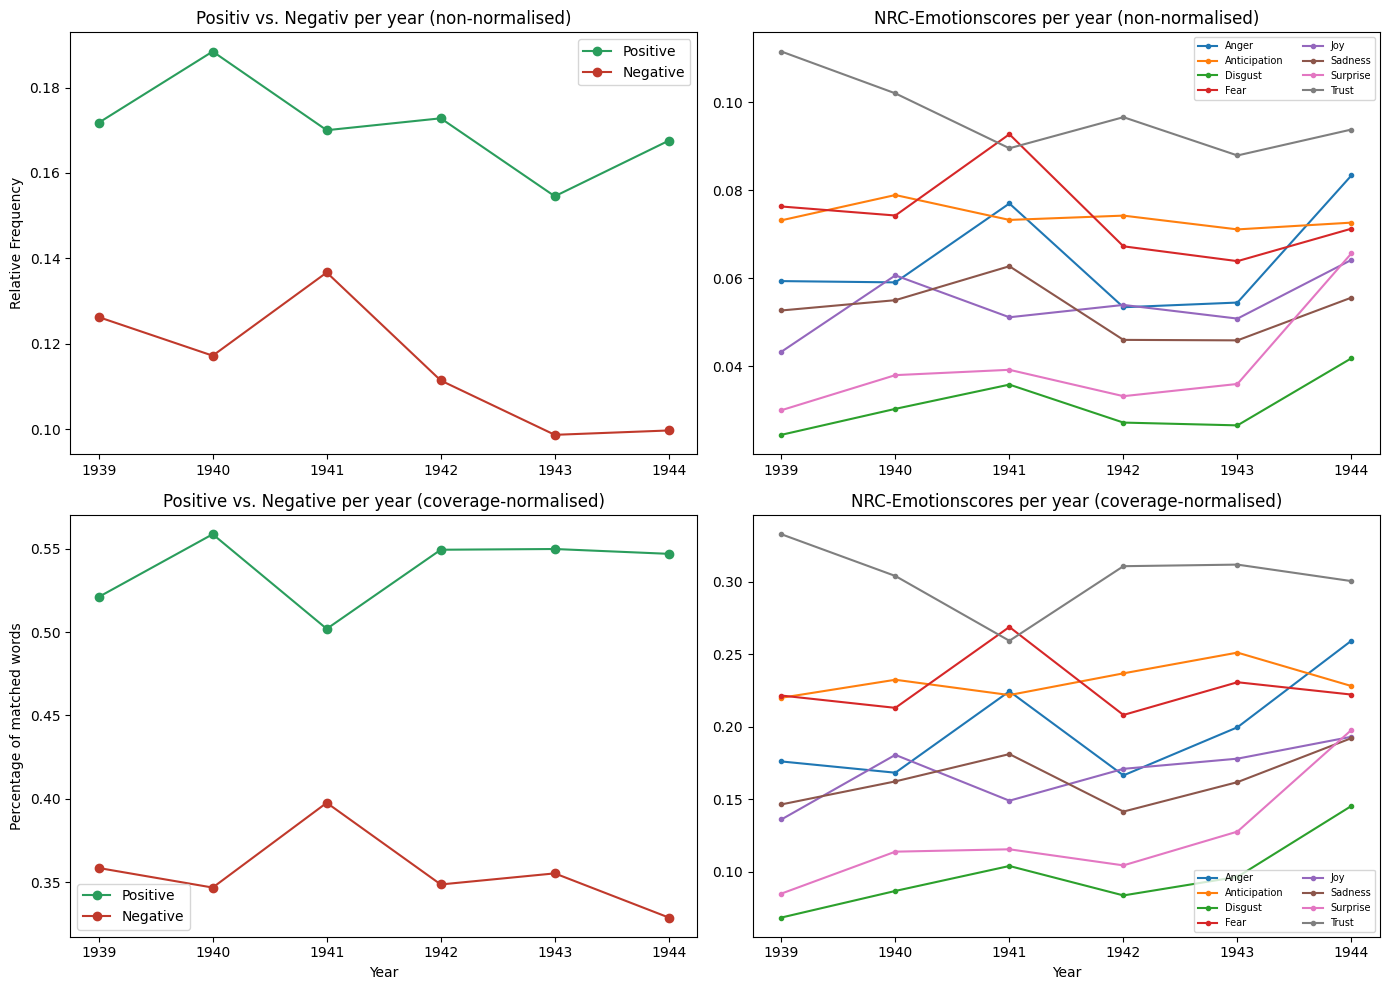

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Oben: roh -- Positiv/Negativ und Basisemotionen
axes[0, 0].plot(yearly["year"], yearly["Positive"], marker="o", label="Positive", color="#2a9d5c")
axes[0, 0].plot(yearly["year"], yearly["Negative"], marker="o", label="Negative", color="#c0392b")
axes[0, 0].set_title("Positiv vs. Negativ per year (non-normalised)")
axes[0, 0].set_ylabel("Relative Frequency")
axes[0, 0].legend()

basic = ["Anger", "Anticipation", "Disgust", "Fear", "Joy", "Sadness", "Surprise", "Trust"]
for e in basic:
    axes[0, 1].plot(yearly["year"], yearly[e], marker=".", label=e)
axes[0, 1].set_title("NRC-Emotionscores per year (non-normalised)")
axes[0, 1].legend(fontsize=7, ncol=2)

# Unten: coverage-normalisiert -- derselbe Vergleich
axes[1, 0].plot(yearly["year"], yearly["Positive_norm"], marker="o", label="Positive", color="#2a9d5c")
axes[1, 0].plot(yearly["year"], yearly["Negative_norm"], marker="o", label="Negative", color="#c0392b")
axes[1, 0].set_title("Positive vs. Negative per year (coverage-normalised)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Percentage of matched words")
axes[1, 0].legend()

for e in basic:
    axes[1, 1].plot(yearly["year"], yearly[f"{e}_norm"], marker=".", label=e)
axes[1, 1].set_title("NRC-Emotionscores per year (coverage-normalised)")
axes[1, 1].set_xlabel("Year")
axes[1, 1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("sentiment_trends.png", dpi=150)
plt.show()


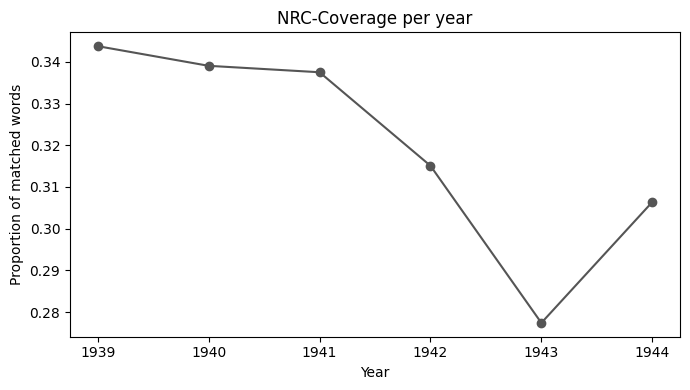

In [125]:
# Zur Einordnung direkt daneben: wie stark faellt die Coverage selbst ueber die Jahre?
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yearly["year"], yearly["nrc_coverage"], marker="o", color="#555")
ax.set_title("NRC-Coverage per year")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of matched words")
plt.tight_layout()
plt.savefig("nrc_coverage.png", dpi=150)
plt.show()



## 7. Artikel nach Emotion ranken (Close Reading)

Für eine genauere qualitative Analyse: die Artikel mit dem höchsten Anteil
einer bestimmten Emotion herausziehen — z. B. um gezielt in die
"wütendsten" oder "hoffnungsvollsten" Artikel eines Jahres reinzulesen.

Hier eignet sich der **rohe** Score (`Fear`, `Joy`, ...) meist besser als
der normalisierte: du suchst ja bewusst Artikel, die *insgesamt* stark
emotional aufgeladen sind, nicht nur relativ zu ihren wenigen gematchten
Wörtern (ein sehr kurzer Artikel mit 2 von 3 gematchten Wörtern in
"Anger" hätte einen sehr hohen `Anger_norm`-Wert, obwohl er insgesamt kaum
Text enthält).


In [126]:
def top_articles_by_emotion(df, emotion, year=None, n=10, save_csv=False, output_path="top_articles.csv"):
    subset = df if year is None else df[df["year"] == year]
    cols = ["pdf_page", "year", "lang", emotion, "text"]
    top_articles = subset.sort_values(emotion, ascending=False).head(n)[cols]

    if save_csv:
        top_articles.to_csv(output_path, index=False)
        print(f"Tabelle gespeichert unter: {output_path}")

    return top_articles


# Beispiel: die 10 Artikel mit dem hoechsten Angst-Anteil, ueber alle Jahre
top_articles_by_emotion(articles, "Fear", n=10, save_csv=True, output_path="CSV/top_fear_articles.csv")


Tabelle gespeichert unter: top_fear_articles.csv


,pdf_page,year,lang,Fear,text
121,30,1940.0,de,0.375000,Der Kampf geht weiter Der entscheidende Faktor...
109,29,1940.0,de,0.319149,Genesung des daenischen Generalkonsuls Der dae...
319,82,1941.0,de,0.312500,itten libysche Haefen und Flugplaetze attackie...
988,222,1943.0,de,0.260870,"tion zu werden, der Obsorge fuer Hilfsbeduerft..."
120,30,1940.0,de,0.257143,Ideale sind staerker In Zeitumstaenden wie den...
321,82,1941.0,de,0.243902,"schwer bombardiert Reuter, London, 7. Juli. Ge..."
436,105,1941.0,de,0.238095,Schlichtungsstelle Die Shanghaier Sondermunizi...
448,108,1941.0,de,0.238095,We Bombenwurf in der Foochow Road In ein chine...
188,50,1940.0,de,0.235294,INDIKATIONEN: Nach der Radiator-Heizung Ein au...
905,209,1943.0,de,0.234043,"setzt, wobei die Angreifer in unregelmaessigen..."


In [155]:
def top_articles_by_emotion(df, emotion, year=None, n=10, save_csv=False, output_path="top_articles.csv"):
    subset = df if year is None else df[df["year"] == year]
    cols = ["pdf_page", "year", "lang", emotion, "text"]
    top_articles = subset.sort_values(emotion, ascending=False).head(n)[cols]

    if save_csv:
        top_articles.to_csv(output_path, index=False)
        print(f"Tabelle gespeichert unter: {output_path}")

    return top_articles


# Beispiel: die 10 Artikel mit dem hoechsten Angst-Anteil, ueber alle Jahre
top_articles_by_emotion(articles, "Joy", n=10, save_csv=True, output_path="CSV/top_joy_articles.csv")


Tabelle gespeichert unter: CSV/top_joy_articles.csv


,pdf_page,year,lang,Joy,text
578,134,1942.0,de,0.260870,Klassiker in Parodie FAUST—3 X RAEUBER—KABALE ...
1002,223,1943.0,de,0.250000,des Jugendtages Anlaesslich der Feiern zum Jug...
607,138,1942.0,de,0.206897,soll um 8 Uhr 80 morgens beginnen und um 6 Uhr...
987,222,1943.0,de,0.200000,SH ANGHAI nenn Wenige Dollars an Kosten heute....
95,24,1940.0,de,0.193548,"losem Sklaventum vorziehen. Wir, werden nicht ..."
710,168,1942.0,de,0.190476,"gedeckter Heizspirale. GASKOCHER mit 1, 2 und ..."
116,29,1940.0,de,0.190476,in Shanghai Starkes Ansteigen der Lebensmittel...
780,183,1942.0,de,0.185185,Helft der Wir Jungen kommen sehr selten in der...
943,214,1943.0,de,0.180556,"Ihr unsichtbarer Gott, der Allgeronwaertige, m..."
134,32,1940.0,de,0.180328,in Amerika Die einzigen gluecklichen Menschen ...


In [154]:
# Beispiel: die 5 "froehlichsten" Artikel je Jahr
top_joy_per_year = (
    articles.sort_values("Joy", ascending=False)
    .groupby("year")
    .head(5)
    .sort_values(["year", "Joy"], ascending=[True, False])
)
top_joy_per_year[["pdf_page", "year", "Joy", "text"]]

# Tabelle als CSV speichern
#top_joy_per_year.to_csv("top_joy_articles_per_year.csv", index=False)
#print("Tabelle gespeichert unter: top_joy_articles_per_year.csv")


,pdf_page,year,Joy,text
79,19,1939.0,0.142857,Massnahmen zur Staerkung der Kriegsschiffe wer...
74,18,1939.0,0.137931,Kindergarten eroeffnen wir Anfang November in ...
59,14,1939.0,0.107143,"Silberwaren, erfahren fuer groessere Geldtrans..."
10,5,1939.0,0.105263,Sport im belgischen Fluechtlingslager In dem O...
91,21,1939.0,0.104167,findet unter dem Protektorat von Miss Cecilia ...
95,24,1940.0,0.193548,"losem Sklaventum vorziehen. Wir, werden nicht ..."
116,29,1940.0,0.190476,in Shanghai Starkes Ansteigen der Lebensmittel...
134,32,1940.0,0.180328,in Amerika Die einzigen gluecklichen Menschen ...
212,56,1940.0,0.166667,Gemeinde in Kobe Eine der groessten juedischen...
170,39,1940.0,0.163265,Chaoufoong-Heim Am 27. September fand vor dem ...


## 8. Ergebnisse speichern


In [128]:
articles.drop(columns=["_lemmas_pos", "_lang_used", "source_file"], errors="ignore").to_csv(
    "articles_with_sentiment.csv", index=False
)
yearly.to_csv("sentiment_by_year.csv", index=False)
print("Gespeichert: articles_with_sentiment.csv, sentiment_by_year.csv, sentiment_trends.png")


Gespeichert: articles_with_sentiment.csv, sentiment_by_year.csv, sentiment_trends.png


## 9. Coverage-Check — bevor du die Ergebnisse interpretierst

**Wichtig:** Wie viel Prozent der Wörter eines Artikels finden überhaupt
ein Match im NRC-Lexikon? Bei historischen/OCR-behafteten Texten kann das
niedrig sein (Rechtschreibvarianten, OCR-Fehler, veraltete Wortformen).

Zwei Muster, auf die du achten solltest:

- **Unterschiedliche Coverage zwischen Gruppen** (z. B. Deutsch vs.
  Englisch, oder frühe vs. späte Jahre): Die *rohen* Scores dieser Gruppen
  sind dann nicht direkt vergleichbar, weil eine Gruppe systematisch mehr
  Wörter "verliert" als die andere. Nutze für solche Vergleiche die
  `_norm`-Spalten (Abschnitt 6 zeigt beide Varianten nebeneinander).
- **Niedrige Coverage bei einzelnen kurzen Artikeln**: Der Score eines
  60-Wörter-Artikels mit nur 3 gematchten Wörtern ist deutlich unsicherer
  als der eines 60-Wörter-Artikels mit 15 gematchten Wörtern — bei über
  viele Artikel gemittelten Jahreswerten gleicht sich das eher aus, bei
  Einzelartikel-Rankings (Abschnitt 7) lohnt ein Blick auf `nrc_coverage`
  mit dazu.


In [129]:
print("NRC-Coverage insgesamt:")
print(articles["nrc_coverage"].describe())

print()
print("Coverage nach Sprache:")
print(articles.groupby("lang")["nrc_coverage"].mean())

print()
print("Coverage nach Jahr (Layout/OCR-Qualitaet kann sich ueber die Zeit veraendern):")
print(articles.groupby("year")["nrc_coverage"].mean())


NRC-Coverage insgesamt:
count    1013.000000
mean        0.319800
std         0.098318
min         0.000000
25%         0.255814
50%         0.323529
75%         0.386207
max         0.658537
Name: nrc_coverage, dtype: float64

Coverage nach Sprache:
lang
de    0.317407
en    0.367906
Name: nrc_coverage, dtype: float64

Coverage nach Jahr (Layout/OCR-Qualitaet kann sich ueber die Zeit veraendern):
year
1939.0    0.343781
1940.0    0.339068
1941.0    0.337525
1942.0    0.315090
1943.0    0.277403
1944.0    0.306390
Name: nrc_coverage, dtype: float64


## 10. Agenturmeldungen vs. redaktionelle Artikel

Agenturmeldungen (Reuter, Transocean, Havas, D.N.B., ...) sind stilistisch
oft nüchterner als redaktionelle Artikel — ein direkter Vergleich zeigt,
ob und wie stark sich das im NRC-Score niederschlägt. Genutzt wird die
Spalte `has_agency_marker` aus der Extraktions-Pipeline.


In [130]:
comparison = (
    articles.groupby("has_agency_marker")[EMOTIONS + NORM_EMOTIONS + ["nrc_coverage", "word_count"]]
    .mean()
    .rename(index={True: "Agency", False: "Editorial"})
)
comparison


,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust,...,Anger_norm,Anticipation_norm,Disgust_norm,Fear_norm,Joy_norm,Sadness_norm,Surprise_norm,Trust_norm,nrc_coverage,word_count
has_agency_marker,,,,,,,,,,,,,,,,,,,,,
Editorial,0.174889,0.113988,0.057787,0.076840,0.029309,0.071496,0.056269,0.050670,0.036771,0.096869,...,0.179429,0.242685,0.089894,0.219333,0.176520,0.155603,0.115602,0.304387,0.319443,169.677704
Agency,0.151550,0.129783,0.072263,0.054326,0.025943,0.086420,0.030219,0.056153,0.025768,0.093834,...,0.217042,0.164081,0.081248,0.263410,0.094482,0.165978,0.075021,0.293405,0.322819,135.289720


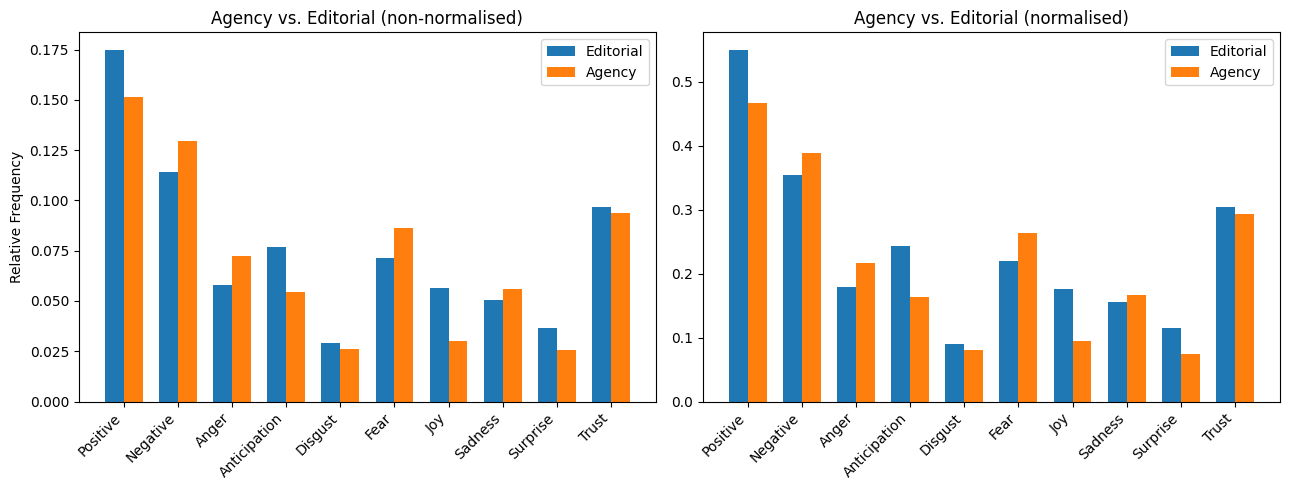

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = range(len(EMOTIONS))
width = 0.35
labels_agency = comparison.index.tolist()

axes[0].bar([i - width/2 for i in x], comparison.loc[labels_agency[0], EMOTIONS], width, label=labels_agency[0])
axes[0].bar([i + width/2 for i in x], comparison.loc[labels_agency[1], EMOTIONS], width, label=labels_agency[1])
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(EMOTIONS, rotation=45, ha="right")
axes[0].set_title("Agency vs. Editorial (non-normalised)")
axes[0].set_ylabel("Relative Frequency")
axes[0].legend()

norm_cols = [f"{e}_norm" for e in EMOTIONS]
axes[1].bar([i - width/2 for i in x], comparison.loc[labels_agency[0], norm_cols], width, label=labels_agency[0])
axes[1].bar([i + width/2 for i in x], comparison.loc[labels_agency[1], norm_cols], width, label=labels_agency[1])
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(EMOTIONS, rotation=45, ha="right")
axes[1].set_title("Agency vs. Editorial (normalised)")
axes[1].legend()

plt.tight_layout()
plt.savefig("sentiment_agency_comparison.png", dpi=150)
plt.show()


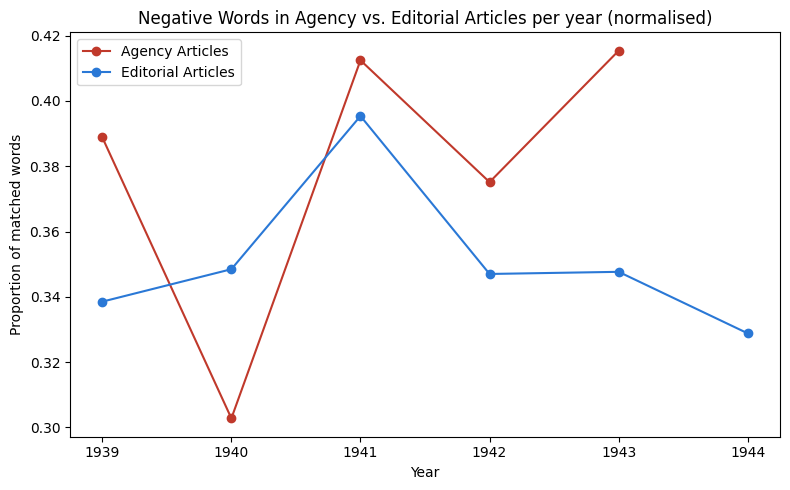

In [132]:
# Dasselbe zusaetzlich nach Jahr aufgeschluesselt -- verlaeuft der
# Unterschied Agentur/redaktionell ueber die Zeit stabil, oder naehern
# sich beide Gruppen an/entfernen sich?
by_year_agency = (
    articles.groupby(["year", "has_agency_marker"])[EMOTIONS + NORM_EMOTIONS]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for is_agency, label, color in [(True, "Agency Articles", "#c0392b"), (False, "Editorial Articles", "#2a78d6")]:
    subset = by_year_agency[by_year_agency["has_agency_marker"] == is_agency]
    ax.plot(subset["year"], subset["Negative_norm"], marker="o", label=label, color=color)
ax.set_title("Negative Words in Agency vs. Editorial Articles per year (normalised)")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of matched words")
ax.legend()
plt.tight_layout()
plt.show()


In [133]:
comparison.to_csv("sentiment_by_agency_marker.csv")
by_year_agency.to_csv("sentiment_by_year_and_agency.csv", index=False)
print("Gespeichert: sentiment_by_agency_marker.csv, sentiment_by_year_and_agency.csv")


Gespeichert: sentiment_by_agency_marker.csv, sentiment_by_year_and_agency.csv


## 11. Thematische Analyse pro Emotion

Was ist inhaltlich typisch für Artikel mit hohem Anteil einer bestimmten
Emotion? Wir nehmen pro Emotion die Top-N-Artikel (nach Roh-Score) und
fassen sie zu **einem** "Dokument" zusammen. Über TF-IDF (verglichen mit
den Dokumenten der anderen Emotionen) ergeben sich die Wörter, die für
genau diese Emotionsgruppe besonders charakteristisch sind — häufig genug
in dieser Gruppe, aber ungewöhnlich selten in den anderen.

**Was das ist und was nicht:** Das ist KEIN eigenständiges Topic-Modeling
(wie LDA) — es lernt keine unabhängigen Themen, sondern zeigt nur, welches
Vokabular jede Emotionsgruppe von den anderen unterscheidet. Dafür ist es
robust auch bei einem Korpus dieser Größe und braucht keine manuelle
Themenbenennung.


In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_N_ARTICLES_PER_EMOTION = 30
TOP_TERMS_TO_SHOW = 15

def build_emotion_topic_words(df, emotions=EMOTIONS, top_n=TOP_N_ARTICLES_PER_EMOTION,
                               top_terms=TOP_TERMS_TO_SHOW):
    """Baut pro Emotion ein "Dokument" aus den Lemmata der Top-N-Artikel
    (nach Roh-Score) und ermittelt per TF-IDF die charakteristischsten
    Woerter dieser Gruppe gegenueber den anderen Emotionsgruppen."""
    emotion_docs = {}
    for e in emotions:
        top = df.sort_values(e, ascending=False).head(top_n)
        words = []
        for lemmas_pos in top["_lemmas_pos"]:
            words.extend(w for w, pos in lemmas_pos)
        emotion_docs[e] = " ".join(words)

    vec = TfidfVectorizer(max_df=0.9, min_df=1)
    tfidf = vec.fit_transform(list(emotion_docs.values()))
    terms = vec.get_feature_names_out()

    results = {}
    for i, e in enumerate(emotions):
        row = tfidf[i].toarray()[0]
        top_idx = row.argsort()[::-1][:top_terms]
        results[e] = [terms[j] for j in top_idx if row[j] > 0]
    return results


# Getrennt nach Sprache, da beide eigene Vokabulare/Lexika haben
print("=== Deutsch ===")
topic_words_de = build_emotion_topic_words(articles[articles["_lang_used"] == "de"])
for e, words in topic_words_de.items():
    print(f"{e:15} {', '.join(words)}")


=== Deutsch ===
Positive        genossenschaft, wort, gemeinde, kuenstler, jugend, preis, mitglied, praesident, hirsch, demokratien, publikum, herr, hilfe, gemeinsam, steigen
Negative        chinesen, schwer, todesfaelle, foreigners, bandit, krieg, bewaffnet, gefaengnis, dringen, erbeuten, typhus, leber, verurteilen, krankheit, haut
Anger           schwer, krieg, angriff, kampf, sept, mailand, england, feindlich, deutschland, groes, schlacht, vernichten, reuter, bombe, bedrohen
Anticipation    anfrage, jugend, kind, politisch, sofort, nachricht, liste, schenken, entspannung, amerika, parade, geschenk, irland, wort, road
Disgust         krankheit, erkrankung, umgebung, typhus, meist, krank, haut, wasser, guenstig, leiden, arzt, fieber, kranken, malaria, infektionskrankheit
Fear            chinesen, todesfaelle, foreigners, krankheit, bomber, proklamation, schwer, krieg, gefaengnis, malta, england, schwanger, malaria, bombe, erfolgen
Joy             garten, musik, freund, feiertage, sams

In [135]:
print("=== Englisch ===")
topic_words_en = build_emotion_topic_words(articles[articles["_lang_used"] == "en"],
                                            top_n=15)  # weniger Artikel verfuegbar
for e, words in topic_words_en.items():
    print(f"{e:15} {', '.join(words)}")


=== Englisch ===
Positive        arab, permit, relation, refugee, council, dear, state, entry, halifax, president, neutrality, assistance, expect, settlement, endeavor
Negative        limited, rubber, estate, arrest, java, limit, ambassador, company, general, detective, communique, master, quiet, rue, halifax
Anger           limited, rubber, estate, neutrality, company, arrest, java, limit, state, master, communique, quiet, rue, detective, circle
Anticipation    chronicle, dear, refugee, council, permit, wish, congratulation, die, president, neutrality, embargo, bloom, success, public, sum
Disgust         die, chronicle, ltd, rubber, asia, wish, congratulation, juden, council, juedischen, arrest, japan, refugee, dear, embargo
Fear            die, chronicle, japan, juden, juedischen, arrest, asia, detective, quiet, rue, master, communique, opportunity, imperial, wish
Joy             chronicle, berglas, dear, ottawa, memorial, emigre, refugee, die, wish, congratulation, plan, public, suc

In [136]:
# Als Tabelle speichern
topic_rows = []
for e, words in topic_words_de.items():
    topic_rows.append({"lang": "de", "emotion": e, "top_terms": ", ".join(words)})
for e, words in topic_words_en.items():
    topic_rows.append({"lang": "en", "emotion": e, "top_terms": ", ".join(words)})
pd.DataFrame(topic_rows).to_csv("CSV/emotion_topic_words.csv", index=False)
print("Gespeichert: emotion_topic_words.csv")


Gespeichert: emotion_topic_words.csv


## 12. Korrelieren bestimmte Diaspora-Gruppen/Regierungen mit Emotionen?

Wir prüfen für eine Reihe historisch interessanter Gruppen (jüdische
Diaspora-Untergruppen), Regierungen/Besatzungsmächte, Hilfsorganisationen
und Kernthemen, ob Artikel, die sie erwähnen, sich in ihrem Emotionsprofil
vom Rest des Korpus unterscheiden.

**Wichtige methodische Einschränkungen, bevor die Zahlen kommen:**

1. **Erkennung per Stichwortsuche** (bilinguale Keyword-Liste, Volltextsuche
   im Rohtext, mit Wortgrenzen `\b...\b`). Ein Treffer bedeutet nur "die
   Gruppe/Institution wird irgendwo im Artikel erwähnt", nicht "der Artikel
   handelt zentral davon". Das verwässert tendenziell echte Effekte (nicht:
   erzeugt sie).
2. **Wortgrenzen sind zwingend, sonst false positives ohne Ende.** Ohne
   `\b...\b` matcht z.B. das Kürzel `IC` als Substring in praktisch jedem
   Wort mit "ic" drin ("wirklich", "politisch") — in einem ersten Test
   schoss dadurch eine Kategorie von plausiblen ~6 auf absurde 961 Treffer
   hoch. Mit Wortgrenzen verschwindet das Problem.
3. **Manche Suchbegriffe bleiben trotzdem zu mehrdeutig und wurden
   entfernt:** `Mir` (Mir-Jeschiwa) ist im Deutschen zugleich das ganz
   normale Pronomen ("sagte mir", "zeigte mir") — Stichprobenprüfung ergab
   63 von 63 Treffern waren das Pronomen, keiner die Jeschiwa. `ORT`
   (Hilfsorganisation) kollidiert genauso mit dem deutschen Wort "Ort/Platz"
   ("an diesem Ort") — auch bei Großschreibung nicht zuverlässig trennbar
   wegen uneinheitlicher OCR-Großschreibung. `Pass` allein lieferte nur
   einen einzigen (falschen) Treffer und wurde entfernt, `Passierschein`/
   `Permit` decken den eigentlich gemeinten Begriff bereits ab.
4. **Stichprobengröße entscheidet, ob ein Test überhaupt sinnvoll ist.**
   Kategorien mit zu wenigen Treffern werden nicht formal getestet, nur
   ihre Trefferzahl gezeigt.
5. **Mehrfachvergleichs-Korrektur ist zwingend:** Bei vielen Themen × 10
   Emotionen findet man sonst allein durch Zufall "signifikante" Treffer.
   Korrektur per Benjamini-Hochberg (FDR) über alle Tests hinweg.
6. **Korrelation, keine Kausalität**, mögliche Störfaktoren (Jahr,
   Agenturmeldung vs. redaktionell, Artikellänge) werden hier NICHT
   kontrolliert.


In [137]:
def _kw_pattern(terms):
    """Baut ein Regex-Suchmuster mit Wortgrenzen um JEDEN Einzelbegriff --
    verhindert Substring-Fehltreffer wie "IC" in "wirklich"."""
    return "|".join(r"\b" + re.escape(t.lower()) + r"\b" for t in terms)


# Bilinguale Stichwortlisten -- pro Kategorie bewusst mit deutschem UND
# englischem Aequivalent, damit Artikel unabhaengig von ihrer Sprache
# gefunden werden (vorherige Version war an mehreren Stellen einsprachig,
# z.B. "SMC & Westmaechte" komplett englisch). "Mir", "ORT", "Pass" bewusst
# NICHT enthalten (siehe Begruendung oben -- zu generische deutsche Woerter,
# an Stichproben ueberprueft: "mir" ausschliesslich das Pronomen, nicht die
# Mir-Jeschiwa; "Ort" ueberwiegend das Wort "Ort/Platz", nicht die
# Organisation ORT).
TOPIC_KEYWORDS = {
    # --- Diaspora-Gruppen ---
    "Central European Refugees (DE/AT)": _kw_pattern([
        "Emigranten","Emigrant","Fluechtlinge","Fluechtling","Refugees","Refugee",
        "Neulaender","Passagiere","Hongkew","Hongkou","Little Vienna","Mitteleuropaeer",
        "Central European","Reichsdeutsche","Austrians","Oesterreicher","German Jews",
        "Deutsche Juden","Heimbeobachter",
    ]),
    "Sephardi Jews": _kw_pattern([
        "Baghdadi","Bagdadi","Sephardim","Sephardic","Sephardische Juden","Sassoon",
        "Kadoorie","Ezra","Hardoon","British Jews","Britische Juden","Iraqi Jews",
        "Irakische Juden","Eastern Jews","Orientalische Juden",
    ]),
    "Russian-Ashkenazi Jews": _kw_pattern([
        "Russische Juden","Russian Jews","Russian Ashkenazi","SAJCA","French Concession",
        "Franzoesische Konzession","Frenchtown","Harbin Jews","Harbiner Juden",
        "Ashkenazi Community","Aschkenasische Gemeinde",
    ]),
    "Polish-Eastern European/Orthodox Groups": _kw_pattern([
        "Polnische Juden","Polish Jews","EASTJEWCOM","Mirer","Yeshiva","Jeschiwa",
        "Rabbiner","Rabbi","Orthodox","Kobe refugees","Kobe Fluechtlinge","Ostjuden",
        "Eastern European Jews","Litauische Juden","Lithuanian Jews",
    ]),
    # --- Regierungen/Besatzung/Behoerden ---
    "SMC & Western powers": _kw_pattern([
        "SMC","Shanghai Municipal Council","Munizipalrat","Municipal","Settlement",
        "International Settlement","Internationale Niederlassung","French Concession",
        "Franzoesische Konzession","Consulate","Konsulat","Consular","Konsularisch",
        "SMP","Special Branch","Ratepayers","Steuerzahler",
    ]),
    "Japanese Occupation Authorities": _kw_pattern([
        "Japanese","Japanisch","Japanese Authorities","Japanische Behoerden",
        "Japanese Military","Japanisches Militaer","Bureau for Stateless Refugees",
        "Inuzuka","Kubota","Ghoya","Okura","Kempeitai","Gendarmerie",
        "Naval Landing Party","Nippon",
    ]),
    "Germany and NS-Regime": _kw_pattern([
        "Generalkonsulat","German Consulate","Deutsches Konsulat","Gestapo","Meisinger",
        "SD","Third Reich","Drittes Reich","Nazi","Auswaertiges Amt","Foreign Office",
    ]),
    "Chinese authorities and the population": _kw_pattern([
        "Chinese","Chinesisch","Chinesen","Nanking Government","Nanking Regierung",
        "Guomindang","Chongqing","Mayor of Shanghai","Buergermeister von Shanghai",
        "Chinese Red Cross","Chinesisches Rotes Kreuz",
    ]),
    "Post-war / US authorities": _kw_pattern([
        "US Army","Amerikanische Armee","UNRRA","CNRRA","American Forces",
        "Amerikanische Truppen","US Consulate","US.Konsulat","Repatriation",
        "Rueckfuehrung","Heimschaffung",
    ]),
    # --- Hilfsorganisationen ---
    "Local relief committees": _kw_pattern([
        "CAEJR","CFA","Speelman Committee","Speelman Komitee","International Committee",
        "Internationales Komitee","Komor Committee","Kitchen Fund","Kuechenfonds",
        "Gemeindevorstand",
    ]),
    "International relief committees": _kw_pattern([
        "JDC","Joint","AJJDC","HIAS","HICEM","ORT","Quakers","Quaeker",
        "Society of Friends","Red Cross","Rotes Kreuz",
    ]),
    "Ghetto- or collaboration organisations": _kw_pattern([
        "SACRA","Joint Administrative Committee","JAC","Pao Chia","Foreign Pao Chia","Paochia",
    ]),
    # --- Kernthemen ---
    "Ghettoisation & Spatial Planning": _kw_pattern([
        "Designated Area","Bezeichnetes Gebiet","Ghetto","Hongkew","Hongkou",
        "Passierschein","Permit","Proclamation","Bekanntmachung","Umsiedlung",
        "Relocation","Heim","Ward Road","Pingliang","Chaoufoong",
    ]),
    "Finance, Work & Emergencies": _kw_pattern([
        "Relief","Unterstuetzung","Finanzen","Finance","Subvention","Spenden","Donations",
        "Dole","Arbeitslosigkeit","Unemployed","Bettler","Beggar","Prostitution",
        "Business","Geschaeft","Pacht","Lease","Inflation","CRB dollars",
    ]),
    "Health, Hygiene & Mortality": _kw_pattern([
        "Krankheit","Disease","Epidemie","Epidemic","Typhus","Dysenterie","Dysentery",
        "Malaria","Hospital","Krankenhaus","Ward Road Hospital","Mangelernaehrung",
        "Malnutrition","Nutritional","Friedhof","Cemetery","Suizid","Suicide",
        "Selbstmord","Sterblichkeit","Mortality","Death rate",
    ]),
    "Culture, Religion & the Press": _kw_pattern([
        "Theater","Konzert","Concert","Zeitung","Newspaper","Press","Presse","Schule",
        "School","Kadoorie School","Synagoge","Synagogue","Koscher","Kosher","Kashrut",
        "Sabbat","Sabbath","Kulturkreis",
    ]),
}

MIN_N_FOR_TEST = 30  # unterhalb dieser Trefferzahl: nicht formal testen

# Hinweis: "ORT" ist trotz Wortgrenzen weiterhin ambivalent (kollidiert mit
# dem deutschen Wort "Ort/Platz", auch grossgeschrieben wegen OCR nicht
# zuverlaessig trennbar) -- in der Kategorie "Internationale Hilfswerke"
# enthalten, aber ihr Ergebnis mit Vorsicht zu lesen, siehe Test oben im
# Chatverlauf. Fuer eine sauberere Version muesste man ORT-Treffer von Hand
# nachpruefen oder auf Anfuehrungszeichen-Kontext ("ORT" in Anfuehrungszeichen
# im Original) einschraenken.

# Erst Trefferzahlen pruefen -- entscheidet, was ueberhaupt testbar ist
topic_counts = {}
topic_masks = {}
for label, pattern in TOPIC_KEYWORDS.items():
    mask = articles["text"].str.contains(pattern, case=False, regex=True, na=False)
    topic_masks[label] = mask
    topic_counts[label] = mask.sum()

counts_df = pd.DataFrame({
    "thema": list(topic_counts.keys()),
    "n_treffer": list(topic_counts.values()),
})
counts_df["testbar"] = counts_df["n_treffer"] >= MIN_N_FOR_TEST
counts_df = counts_df.sort_values("n_treffer", ascending=False)
print(counts_df.to_string(index=False))
counts_df.to_csv("topic_keyword_counts.csv", index=False)
print("Tabelle als 'topic_keyword_counts.csv' gespeichert.")


                                  thema  n_treffer  testbar
      Central European Refugees (DE/AT)        149     True
          Culture, Religion & the Press        137     True
       Ghettoisation & Spatial Planning         81     True
        International relief committees         51     True
            Finance, Work & Emergencies         50     True
            Health, Hygiene & Mortality         46     True
                   SMC & Western powers         36     True
 Chinese authorities and the population         33     True
        Japanese Occupation Authorities         27    False
Polish-Eastern European/Orthodox Groups         16    False
 Ghetto- or collaboration organisations          9    False
                          Sephardi Jews          7    False
                 Russian-Ashkenazi Jews          7    False
                  Germany and NS-Regime          6    False
                Local relief committees          2    False
              Post-war / US authorities 

In [138]:
NORM_COLS = [f"{e}_norm" for e in EMOTIONS]

testable_topics = counts_df[counts_df["testbar"]]["thema"].tolist()
print(f"Formal testbare Themen (n >= {MIN_N_FOR_TEST}): {testable_topics}")
print(f"NICHT testbar (zu wenige Treffer): "
      f"{counts_df[~counts_df['testbar']]['thema'].tolist()}")

rows = []
for label in testable_topics:
    mask = topic_masks[label]
    group_yes = articles[mask]
    group_no = articles[~mask]
    for e_norm in NORM_COLS:
        emotion = e_norm.replace("_norm", "")
        vals_yes = group_yes[e_norm].dropna()
        vals_no = group_no[e_norm].dropna()
        stat, p = stats.mannwhitneyu(vals_yes, vals_no, alternative="two-sided")
        n1, n2 = len(vals_yes), len(vals_no)
        # Rangbiseriale Korrelation als Effektstaerke (-1 bis 1); positiv =
        # Thema-Gruppe hat tendenziell HOEHERE Werte als der Rest des Korpus
        # (Vorzeichen bewusst so gewaehlt, dass es zu den median_thema/
        # median_rest-Spalten direkt daneben passt -- leichter lesbar).
        effect = (2 * stat) / (n1 * n2) - 1
        rows.append({
            "thema": label, "emotion": emotion, "n_thema": n1, "n_rest": n2,
            "median_thema": vals_yes.median(), "median_rest": vals_no.median(),
            "effektstaerke": effect, "p_roh": p,
        })

topic_emotion_tests = pd.DataFrame(rows)
topic_emotion_tests["p_adj_fdr"] = multipletests(topic_emotion_tests["p_roh"], method="fdr_bh")[1]
topic_emotion_tests["signifikant"] = topic_emotion_tests["p_adj_fdr"] < 0.05
topic_emotion_tests = topic_emotion_tests.sort_values("p_adj_fdr")

print(f"\n{len(topic_emotion_tests)} Tests durchgefuehrt, "
      f"{topic_emotion_tests['signifikant'].sum()} signifikant nach FDR-Korrektur:\n")
topic_emotion_tests[["thema","emotion","median_thema","median_rest","effektstaerke","p_adj_fdr","signifikant"]]


Formal testbare Themen (n >= 30): ['Central European Refugees (DE/AT)', 'Culture, Religion & the Press', 'Ghettoisation & Spatial Planning', 'International relief committees', 'Finance, Work & Emergencies', 'Health, Hygiene & Mortality', 'SMC & Western powers', 'Chinese authorities and the population']
NICHT testbar (zu wenige Treffer): ['Japanese Occupation Authorities', 'Polish-Eastern European/Orthodox Groups', 'Ghetto- or collaboration organisations', 'Sephardi Jews', 'Russian-Ashkenazi Jews', 'Germany and NS-Regime', 'Local relief committees', 'Post-war / US authorities']

80 Tests durchgefuehrt, 13 signifikant nach FDR-Korrektur:



,thema,emotion,median_thema,median_rest,effektstaerke,p_adj_fdr,signifikant
55,"Health, Hygiene & Mortality",Fear,0.333333,0.200000,0.573760,3.642069e-09,True
54,"Health, Hygiene & Mortality",Disgust,0.171569,0.071429,0.554899,4.845423e-09,True
51,"Health, Hygiene & Mortality",Negative,0.474375,0.340426,0.511443,1.172790e-07,True
57,"Health, Hygiene & Mortality",Sadness,0.241878,0.136986,0.500450,1.740379e-07,True
11,"Culture, Religion & the Press",Negative,0.301887,0.356538,-0.249358,3.472539e-05,True
...,...,...,...,...,...,...,...
43,"Finance, Work & Emergencies",Anticipation,0.230605,0.222222,-0.003011,9.838143e-01,False
64,SMC & Western powers,Disgust,0.073372,0.071429,0.003753,9.838143e-01,False
63,SMC & Western powers,Anticipation,0.217067,0.222222,0.009581,9.838143e-01,False
73,Chinese authorities and the population,Anticipation,0.232143,0.222222,0.005782,9.838143e-01,False


In [139]:
# Nur signifikante Befunde im Klartext
sig = topic_emotion_tests[topic_emotion_tests["signifikant"]]
if sig.empty:
    print("Kein einziger Zusammenhang übersteht die Mehrfachvergleichs-Korrektur.")
    print("Alles, was auf den ersten Blick nach einem Muster aussieht, ist mit")
    print("diesem Korpusumfang statistisch nicht von Zufall zu unterscheiden.")
else:
    for _, row in sig.iterrows():
        richtung = "hoeher" if row["effektstaerke"] > 0 else "niedriger"
        print(f"{row['thema']}: {row['emotion']} signifikant {richtung} "
              f"(Median {row['median_thema']:.3f} vs. {row['median_rest']:.3f} sonst, "
              f"Effektstaerke {row['effektstaerke']:.2f}, p_adj={row['p_adj_fdr']:.3f})")


Health, Hygiene & Mortality: Fear signifikant hoeher (Median 0.333 vs. 0.200 sonst, Effektstaerke 0.57, p_adj=0.000)
Health, Hygiene & Mortality: Disgust signifikant hoeher (Median 0.172 vs. 0.071 sonst, Effektstaerke 0.55, p_adj=0.000)
Health, Hygiene & Mortality: Negative signifikant hoeher (Median 0.474 vs. 0.340 sonst, Effektstaerke 0.51, p_adj=0.000)
Health, Hygiene & Mortality: Sadness signifikant hoeher (Median 0.242 vs. 0.137 sonst, Effektstaerke 0.50, p_adj=0.000)
Culture, Religion & the Press: Negative signifikant niedriger (Median 0.302 vs. 0.357 sonst, Effektstaerke -0.25, p_adj=0.000)
Health, Hygiene & Mortality: Positive signifikant niedriger (Median 0.438 vs. 0.543 sonst, Effektstaerke -0.41, p_adj=0.000)
Culture, Religion & the Press: Anger signifikant niedriger (Median 0.138 vs. 0.173 sonst, Effektstaerke -0.22, p_adj=0.000)
Culture, Religion & the Press: Fear signifikant niedriger (Median 0.167 vs. 0.219 sonst, Effektstaerke -0.22, p_adj=0.000)
Health, Hygiene & Morta

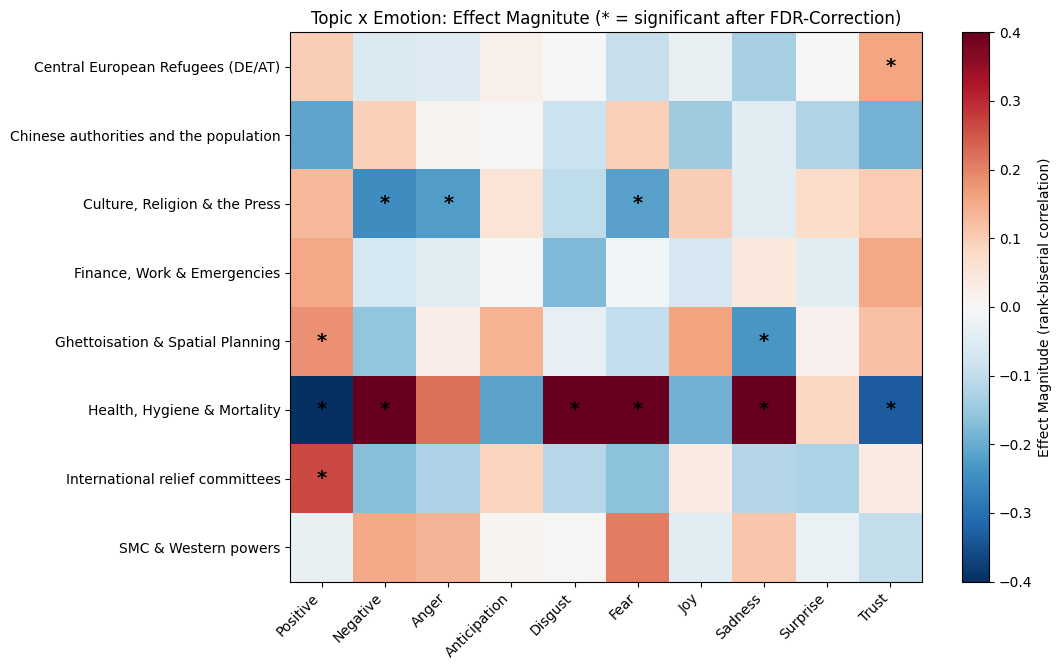

Gespeichert: topic_emotion_tests.csv, topic_keyword_counts.csv, heatmap.png


In [140]:
import numpy as np

# Heatmap der Effektstaerken fuer die testbaren Themen -- Signifikanz markiert
pivot = topic_emotion_tests.pivot(index="thema", columns="emotion", values="effektstaerke")
pivot = pivot[EMOTIONS]  # feste Spaltenreihenfolge
sig_pivot = topic_emotion_tests.pivot(index="thema", columns="emotion", values="signifikant")[EMOTIONS]

fig, ax = plt.subplots(figsize=(11, 0.6 * len(pivot) + 2))
im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_xticks(range(len(EMOTIONS)))
ax.set_xticklabels(EMOTIONS, rotation=45, ha="right")
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot)):
    for j in range(len(EMOTIONS)):
        if sig_pivot.values[i, j]:
            ax.text(j, i, "*", ha="center", va="center", color="black", fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax, label="Effect Magnitude (rank-biserial correlation)")
ax.set_title("Topic x Emotion: Effect Magnitute (* = significant after FDR-Correction)")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

topic_emotion_tests.to_csv("topic_emotion_tests.csv", index=False)
counts_df.to_csv("topic_keyword_counts.csv", index=False)
print("Gespeichert: topic_emotion_tests.csv, topic_keyword_counts.csv, heatmap.png")

# Jetzt koennen die Hilfsspalten final entfernt werden
articles = articles.drop(columns=["_lemmas_pos", "_lang_used"], errors="ignore")


## Wie es weitergeht

- Für Jahres-/Sprachvergleiche primär die `_norm`-Spalten verwenden, für
  Einzelartikel-Ranking und "Gesamt-Textstimmung" primär die rohen Spalten.
- Stichprobenartig ein paar Artikel mit sehr hohem/niedrigem Score von
  Hand gegenlesen — passt der NRC-Score zum tatsächlichen Ton des
  Artikels?
- `FUZZY_SCORE_CUTOFF` (Abschnitt 5b) ist ein erster konservativer Wert —
  bei Bedarf ein paar zufällige Korrekturpaare aus `fuzzy_de`/`fuzzy_en`
  von Hand gegenlesen, um zu prüfen, ob die Schwelle passt.
- Falls die TF-IDF-Wortlisten (Abschnitt 11) zu grob wirken oder du
  eigenständige, von Emotionen unabhängige Themen willst: echtes
  Topic-Modeling (LDA/NMF, z.B. über `sklearn.decomposition`) wäre der
  nächste Schritt — mit mehr manuellem Interpretationsaufwand (Themen
  müssen benannt werden) und ist bei diesem Korpusumfang eher lohnend,
  wenn du gezielt mit verschiedenen Themenzahlen experimentierst.


In [156]:
def _latex_safe(text):
    """Escaped Unterstriche fuer die Verwendung in \\caption/\\label
    (Fliesstext, kein Mathe-Modus) -- sonst bricht pdflatex mit
    "Missing $ inserted" ab, sobald der Dateiname (z.B. "top_fear_articles")
    einen Unterstrich enthaelt."""
    return text.replace('_', '-')


def _needs_wrapping(series, threshold=40):
    """Erkennt Spalten mit langem Fliesstext (z.B. Artikelausschnitte) --
    die brauchen eine feste Breite MIT Zeilenumbruch, sonst laeuft die
    Tabelle als eine einzige, extrem breite Zeile ueber den Papierrand
    hinaus (Overfull \\hbox)."""
    lengths = series.astype(str).str.len()
    return lengths.mean() > threshold


def _add_grid_lines(latex_str):
    """Wandelt den booktabs-Stil (nur \\toprule/\\midrule/\\bottomrule,
    keine vertikalen Linien) in ein klassisches Gitternetz um: \\hline
    nach JEDER Zeile (Kopf- und Datenzeilen), Vertikale Striche kommen
    separat ueber das column_format (siehe unten, "|r|r|...|")."""
    latex_str = latex_str.replace(r'\toprule', r'\hline')
    latex_str = latex_str.replace(r'\midrule', r'\hline')
    latex_str = latex_str.replace(r'\bottomrule', r'\hline')

    lines = latex_str.split('\n')
    out = []
    for i, line in enumerate(lines):
        out.append(line)
        stripped = line.strip()
        # Nur echte Tabellenzeilen (Kopf- oder Datenzeilen: enthalten "&"
        # und enden auf "\\") bekommen zusaetzlich ein \hline danach.
        if stripped.endswith(r'\\') and '&' in stripped:
            next_stripped = lines[i + 1].strip() if i + 1 < len(lines) else ''
            if next_stripped != r'\hline':  # kein doppeltes \hline erzeugen
                out.append(r'\hline')
    return '\n'.join(out)


def process_all_csvs(input_dir, output_dir, text_col_width='6cm', drop_columns=None,
                      skip_files=None):
    """drop_columns: Liste von Spaltennamen, die (falls vorhanden) VOR der
    LaTeX-Erzeugung aus JEDER CSV entfernt werden -- z.B. "source_file", das
    in fast jeder Zeile ohnehin denselben Wert hat und nur unnoetig Breite
    kostet. Namen werden unabhaengig von Gross-/Kleinschreibung UND davon,
    ob im Original "_" oder "-" verwendet wurde, erkannt. Bei CSVs, die die
    Spalte gar nicht haben, passiert einfach nichts (kein Fehler).

    skip_files: Dateinamen (ohne Pfad, mit oder ohne ".csv"), die KOMPLETT
    uebersprungen werden -- z.B. fuer Rohdaten-CSVs mit sehr vielen Spalten
    (wie "articles_with_sentiment.csv" mit 20+ Emotions-Spalten), die sich
    grundsaetzlich nicht sinnvoll auf eine gedruckte Seite quetschen lassen,
    egal wie schmal man die einzelnen Spalten macht. Fuer solche Dateien:
    entweder eine eigene, kuratierte CSV mit nur den relevanten Spalten
    erzeugen (z.B. per pandas: df[["pdf-page","year","lang","Fear","text"]])
    und die separat konvertieren, oder ganz auf eine LaTeX-Tabelle verzichten
    und stattdessen z.B. nur die Diagramme/Heatmaps dafuer einbinden.
    """
    drop_columns = drop_columns or []
    drop_normalized = {c.lower().replace('_', '-') for c in drop_columns}
    skip_files = skip_files or []
    skip_normalized = {os.path.splitext(f)[0].lower() for f in skip_files}

    os.makedirs(output_dir, exist_ok=True)

    for csv_file in glob.glob(os.path.join(input_dir, '*.csv')):
        base_check = os.path.splitext(os.path.basename(csv_file))[0].lower()
        if base_check in skip_normalized:
            print(f"Uebersprungen (zu viele Spalten fuer Druck): {csv_file}")
            continue

        df = pd.read_csv(csv_file)

        # Unerwuenschte Spalten VOR allem anderen entfernen
        cols_to_drop = [c for c in df.columns
                         if c.lower().replace('_', '-') in drop_normalized]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)

        # Unterstriche in (verbleibenden) Spaltennamen durch Bindestriche ersetzen
        df.columns = [str(col).replace('_', '-') for col in df.columns]

        # Spaltenformat dynamisch bestimmen: numerische Spalten rechtsbuendig,
        # lange Textspalten als feste, umbrechende Breite (verhindert das
        # Overfull-hbox-Problem), alles andere normal linksbuendig.
        # Vertikale Striche "|" zwischen JEDER Spalte UND am Anfang/Ende.
        col_format = []
        for col in df.columns:
            if pd.api.types.is_numeric_dtype(df[col]):
                col_format.append('r')
            elif not pd.api.types.is_numeric_dtype(df[col]) and _needs_wrapping(df[col]):
                col_format.append(f'p{{{text_col_width}}}')
            else:
                col_format.append('l')
        column_format = '|' + '|'.join(col_format) + '|'

        base_name = os.path.splitext(os.path.basename(csv_file))[0]
        tex_filename = f"{base_name}_table.tex"
        safe_name = _latex_safe(base_name)  # fuer caption/label

        latex_table = df.to_latex(
            index=False,
            float_format='%.3f',
            caption=f'Results from {safe_name}',
            label=f'tab:{safe_name}',
            escape=True,          # Sonderzeichen in Zellinhalten escapen
            column_format=column_format,  # feste Spaltenbreiten + vertikale Linien
            longtable=True,       # Tabelle darf ueber mehrere Seiten laufen
                                   # (bei langen Textspalten/vielen Zeilen
                                   # sonst passt die Tabelle nicht mehr auf
                                   # eine Seite -> braucht longtable-Paket!)
        )
        latex_table = _add_grid_lines(latex_table)  # \hline nach jeder Zeile

        with open(os.path.join(output_dir, tex_filename), 'w', encoding='utf-8') as f:
            f.write(latex_table)

        print(f"Processed {csv_file} → {tex_filename}")


# Usage
process_all_csvs(
    'CSV', 'LatexTables',
    drop_columns=['source_file'],
    skip_files=['articles_with_sentiment'],  # Rohdaten -- zu viele Spalten fuer Druck
)


Processed CSV\emotion_topic_words.csv → emotion_topic_words_table.tex
Processed CSV\sentiment_by_year.csv → sentiment_by_year_table.tex
Processed CSV\topic_keyword_counts.csv → topic_keyword_counts_table.tex
Processed CSV\top_fear_articles.csv → top_fear_articles_table.tex
Processed CSV\top_joy_articles.csv → top_joy_articles_table.tex
Processed CSV\top_joy_articles_per_year.csv → top_joy_articles_per_year_table.tex
Processed CSV\top_joy_per_year.csv → top_joy_per_year_table.tex
